
Analyzing Event 74: Total active hits = 431,640

             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 161,512
SIGNAL hitIDs (Hits >= 4)   : 34,412
BACKGROUND hitIDs (Hits < 4): 127,100
------------------------------------------------------------

Sample SIGNAL Track hitIDs (Long, continuous paths):
      hitID  track_multiplicity  span_layers
150930240.0                  89         16.0
 67239968.0                  53         38.0
150930256.0                  46         16.0
 59179064.0                  45         19.0
 44434160.0                  43         16.0
 44434164.0                  43         16.0
 59244600.0                  42         19.0
 43516152.0                  42         13.0
 44434168.0                  41         16.0
 44368624.0                  40         16.0

Sample BACKGROUND hitIDs (Isolated noise / delta rays):
 hitID  track_multiplicity  span_layers
   0.0                   1          1.0
   1.0                   2      

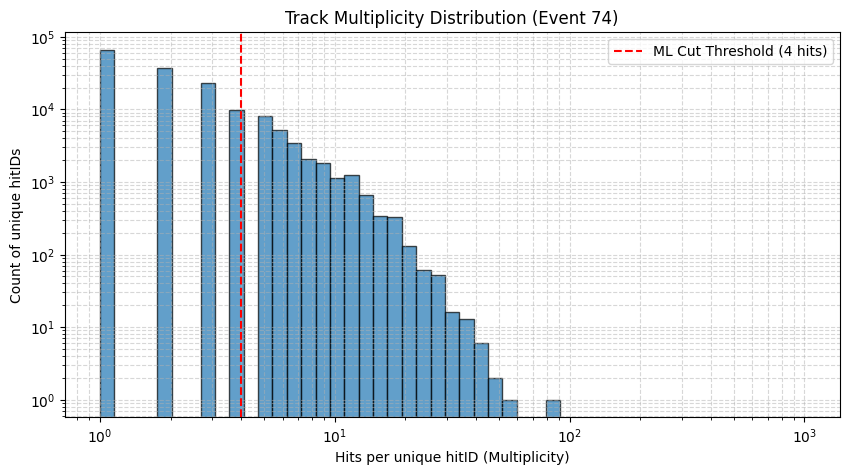

In [10]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "../clusters_seeds_island_79507-0.root_ntuplizer.root"
tree = uproot.open(file_path)["ntp_hit"]

df = tree.arrays(["event", "layer", "hitID", "adc"], library="pd")
df = df[df["adc"] > 0]

# (Let's select Event 74 as our benchmark)
target_event = 74
event_df = df[df["event"] == target_event]

print(f"\nAnalyzing Event {target_event}: Total active hits = {len(event_df):,}")

# 3. Calculate the multiplicity (size) of each unique hitID
track_sizes = event_df.groupby("hitID").size().reset_index(name="track_multiplicity")

# Merge multiplicity back to see the layer span of each hitID
track_layer_spans = event_df.groupby("hitID")["layer"].agg(
    span_layers=lambda x: x.max() - x.min() + 1
).reset_index()

hit_profiles = pd.merge(track_sizes, track_layer_spans, on="hitID")

# 4. Define Threshold Criteria for Signal vs. Background Noise (Purely EXPERIMENTAL)
# Standard physics tracks usually require at least 4 hits to form a seed track stub
min_signal_hits = 4 

signal_profiles = hit_profiles[hit_profiles["track_multiplicity"] >= min_signal_hits]
background_profiles = hit_profiles[hit_profiles["track_multiplicity"] < min_signal_hits]

# 5. Extract the explicit lists of hitID values
signal_hit_ids = signal_profiles["hitID"].tolist()
background_hit_ids = background_profiles["hitID"].tolist()

print("\n" + "="*60)
print("             HIT ID CLASSIFICATION SUMMARY             ")
print("="*60)
print(f"Total Unique hitIDs Found     : {len(hit_profiles):,}")
print(f"SIGNAL hitIDs (Hits >= {min_signal_hits})   : {len(signal_hit_ids):,}")
print(f"BACKGROUND hitIDs (Hits < {min_signal_hits}): {len(background_hit_ids):,}")
print("-"*60)

# Print a few examples of verified Signal Track IDs
print("\nSample SIGNAL Track hitIDs (Long, continuous paths):")
print(signal_profiles.sort_values(by="track_multiplicity", ascending=False).head(10).to_string(index=False))

# Print a few examples of verified Background Clutter IDs
print("\nSample BACKGROUND hitIDs (Isolated noise / delta rays):")
print(background_profiles.head(10).to_string(index=False))
print("="*60)

# 6. Optional: Create a Verification Plot to validate the threshold selection
plt.figure(figsize=(10, 5))
plt.hist(hit_profiles["track_multiplicity"], bins=np.logspace(0, 3, 50), edgecolor='k', alpha=0.7)
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.axvline(x=min_signal_hits, color='r', linestyle='--', label=f'ML Cut Threshold ({min_signal_hits} hits)')
plt.xlabel("Hits per unique hitID (Multiplicity)")
plt.ylabel("Count of unique hitIDs")
plt.title(f"Track Multiplicity Distribution (Event {target_event})")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.savefig(f"../Visualizing/images/hitID_multiplicity_distribution_Event{target_event}.png", bbox_inches='tight')
print("\nMultiplicity diagnosis plot saved as 'hitID_multiplicity_distribution.png'.")

In [12]:
import uproot
import pandas as pd
import numpy as np

file_path = "../clusters_seeds_island_79507-0.root_ntuplizer.root"
tree = uproot.open(file_path)["ntp_hit"]
df = tree.arrays(["event", "hitID", "adc"], library="pd")

df = df[df["adc"] > 0]
print(f"Total active hits loaded: {len(df):,}")

print("Calculating track multiplicities across the entire dataset...")
track_counts = df.groupby(["event", "hitID"]).size().reset_index(name="multiplicity")

# 3. Define the ML signal cutoff threshold (A Guess)
min_signal_hits = 4

# Add binary classification flag: 1 for real track signal, 0 for micro-noise/background
track_counts["is_signal"] = (track_counts["multiplicity"] >= min_signal_hits).astype(int)

# 4. Aggregate the final summary metrics per event
print("Aggregating signal vs background distributions...")
event_grouped = df.groupby("event")
total_hits_per_event = event_grouped.size()

summary_grouped = track_counts.groupby("event")
event_summary = summary_grouped.agg(
    unique_hit_ids=("hitID", "count"),
    signal_tracks=("is_signal", "sum"),
).reset_index()

# Map total hits back to the summary table
event_summary["total_active_hits"] = event_summary["event"].map(total_hits_per_event)
# Background tracks = Total unique IDs - Signal tracks
event_summary["background_tracks"] = event_summary["unique_hit_ids"] - event_summary["signal_tracks"]

# Ensure integer types for cleaner printing
event_summary = event_summary.astype(int)

# 5. Print out the formatted report for all 100 events sequentially
print("\n" + "="*60)
print("       ALL EVENTS GROUND-TRUTH SEPARATION AUDIT        ")
print("="*60)

for _, row in event_summary.iterrows():
    ev = row["event"]
    print(f"Analyzing Event {ev}: Total active hits = {row['total_active_hits']:,}")
    print(f"============================================================")
    print(f"             HIT ID CLASSIFICATION SUMMARY             ")
    print(f"============================================================")
    print(f"Total Unique hitIDs Found     : {row['unique_hit_ids']:,}")
    print(f"SIGNAL (Guess) hitIDs (Hits >= {min_signal_hits})   : {row['signal_tracks']:,}")
    print(f"BACKGROUND (Guess) hitIDs (Hits < {min_signal_hits}): {row['background_tracks']:,}")
    print(f"------------------------------------------------------------\n")

# 6. Save the master report as a CSV for model benchmarking
output_csv = "all_events_hitID_summary.csv"
event_summary.to_csv(output_csv, index=False)
print(f"Global cross-event summary saved successfully to '{output_csv}'.")

Total active hits loaded: 25,869,501
Calculating track multiplicities across the entire dataset...
Aggregating signal vs background distributions...

       ALL EVENTS GROUND-TRUTH SEPARATION AUDIT        
Analyzing Event 1: Total active hits = 58,339
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 23,825
SIGNAL (Guess) hitIDs (Hits >= 4)   : 4,512
BACKGROUND (Guess) hitIDs (Hits < 4): 19,313
------------------------------------------------------------

Analyzing Event 2: Total active hits = 197,229
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 76,157
SIGNAL (Guess) hitIDs (Hits >= 4)   : 15,480
BACKGROUND (Guess) hitIDs (Hits < 4): 60,677
------------------------------------------------------------

Analyzing Event 3: Total active hits = 123,553
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 50,268
SIGNAL (Guess) hitIDs (Hits >= 4)   : 9,453
BACKGROUND (Guess) hit

In [ ]:
#   Continuous Analysis following the above CSV file:
# 1. Load the generated summary data
csv_file = "all_events_hitID_summary.csv"
try:
    df = pd.read_csv(csv_file)
except FileNotFoundError:
    print(f"Error: Could not find '{csv_file}'. Make sure it is in your current directory.")
    exit()

# Ensure standard column names and sorting
df = df.sort_values(by="event").reset_index(drop=True)

# 2. Sequentially loop over all events and display the customized summary block
print("=" * 60)
print("       ALL 100 EVENTS GROUND-TRUTH SEPARATION AUDIT       ")
print("=" * 60)

for _, row in df.iterrows():
    # Parse metrics safely as integers
    ev = int(row["event"])
    total_hits = int(row["total_active_hits"])
    unique_ids = int(row["unique_hit_ids"])
    signal_tracks = int(row["signal_tracks"])
    bg_tracks = int(row["background_tracks"])
    
    # Calculate percentage-based metrics for better context
    bg_percentage = (bg_tracks / unique_ids) * 100 if unique_ids > 0 else 0
    
    print(f"Analyzing Event {ev}: Total active hits = {total_hits:,}")
    print(f"============================================================")
    print(f"             HIT ID CLASSIFICATION SUMMARY             ")
    print(f"============================================================")
    print(f"Total Unique hitIDs Found     : {unique_ids:,}")
    print(f"SIGNAL hitIDs (Hits >= 4)   : {signal_tracks:,}")
    print(f"BACKGROUND hitIDs (Hits < 4): {bg_tracks:,} ({bg_percentage:.2f}% of IDs)")
    print(f"------------------------------------------------------------\n")

# 3. Compute Global Cross-Event Multiplicity & Noise Extremes for ML Batching
print("=" * 60)
print("            MASTER ML TRAINING SPLIT INSIGHTS             ")
print("=" * 60)

# Find busiest and quietest collision environments
idx_max_hits = df["total_active_hits"].idxmax()
idx_min_hits = df["total_active_hits"].idxmin()

# Calculate signal-to-noise ratio per event (Signal tracks / Background tracks)
df["snr"] = df["signal_tracks"] / df["background_tracks"]
idx_max_snr = df["snr"].idxmax()
idx_min_snr = df["snr"].idxmin()

print(f"Total Events Audited            : {len(df)}")
print(f"Average Active Hits/Event       : {df['total_active_hits'].mean():,.1f}")
print(f"Global Signal Track Base        : {df['signal_tracks'].sum(),}")
print(f"Global Micro-Noise Tracker Base : {df['background_tracks'].sum(),}")
print(f"Dataset-Wide Tracking Purity    : {(df['signal_tracks'].sum() / df['unique_hit_ids'].sum()) * 100:.2f}%")
print("-" * 60)
print(f"🔥 Busiest Event (High Occupancy Testing) : Event {int(df.loc[idx_max_hits, 'event'])} with {int(df.loc[idx_max_hits, 'total_active_hits']):,} hits")
print(f"❄️  Quietest Event (Clean Baseline Testing): Event {int(df.loc[idx_min_hits, 'event'])} with {int(df.loc[idx_min_hits, 'total_active_hits']):,} hits")
print(f"📈 Cleanest Event (Highest SNR ratio)      : Event {int(df.loc[idx_max_snr, 'event'])} (SNR: {df.loc[idx_max_snr, 'snr']:.4f})")
print(f"📉 Messiest Event (Lowest SNR / High Noise) : Event {int(df.loc[idx_min_snr, 'event'])} (SNR: {df.loc[idx_min_snr, 'snr']:.4f})")
print("=" * 60)

       ALL 100 EVENTS GROUND-TRUTH SEPARATION AUDIT       
Analyzing Event 1: Total active hits = 58,339
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 23,825
SIGNAL hitIDs (Hits >= 4)   : 4,512
BACKGROUND hitIDs (Hits < 4): 19,313 (81.06% of IDs)
------------------------------------------------------------

Analyzing Event 2: Total active hits = 197,229
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 76,157
SIGNAL hitIDs (Hits >= 4)   : 15,480
BACKGROUND hitIDs (Hits < 4): 60,677 (79.67% of IDs)
------------------------------------------------------------

Analyzing Event 3: Total active hits = 123,553
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 50,268
SIGNAL hitIDs (Hits >= 4)   : 9,453
BACKGROUND hitIDs (Hits < 4): 40,815 (81.19% of IDs)
------------------------------------------------------------

Analyzing Event 4: Total active hits = 123,201
             HI